In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random


In [28]:
feedback = pd.read_csv("../outputs/agent_feedback_history.csv")

feedback = feedback.sort_values("time_window")

feedback.head()

,customer_unique_id,persona,agent_action,time_window,feedback_outcome,feedback_score,total_feedback_score,num_actions,num_positive,num_negative,num_churn
31095,c0d844c11288762f18fc24cc79093a80,Silent Loyal Customers,No Action,W1,no_response,0.0,0.0,1,0,0,0
23934,94b7e216737623dc935a685037d1eb21,Silent Loyal Customers,No Action,W1,positive_response,1.0,1.0,1,1,0,0
23933,94b731a41867b47c3856e324840c4c99,Emerging Loyalists,Personalized Discount Offer,W1,negative_response,-0.5,-0.5,1,0,1,0
11820,4957e6259456f901c8aebe84bab0e4aa,Emerging Loyalists,Personalized Discount Offer,W1,churned,-1.0,-1.0,1,0,0,1
23932,94b72e6821934cf7dbc0621dec75ddea,Emerging Loyalists,Personalized Discount Offer,W1,positive_response,1.0,1.0,1,1,0,0


In [29]:
reward_map = {
    "positive_response": 8,
    "negative_response": -3,
    "churned": -10,
    "no_response": -2
}

action_cost_map = {
    "No Action": 0,
    "Personalized Discount Offer": 2,
    "Win-Back Campaign": 3,
    "Loyalty Points + Feedback Request": 1
}

In [30]:
feedback["reward"] = feedback["feedback_outcome"].map(reward_map)
feedback["action_cost"] = feedback["agent_action"].map(action_cost_map)

feedback["net_reward"] = feedback["reward"] - feedback["action_cost"]

feedback.head()

,customer_unique_id,persona,agent_action,time_window,feedback_outcome,feedback_score,total_feedback_score,num_actions,num_positive,num_negative,num_churn,reward,action_cost,net_reward
31095,c0d844c11288762f18fc24cc79093a80,Silent Loyal Customers,No Action,W1,no_response,0.0,0.0,1,0,0,0,-2,0,-2
23934,94b7e216737623dc935a685037d1eb21,Silent Loyal Customers,No Action,W1,positive_response,1.0,1.0,1,1,0,0,8,0,8
23933,94b731a41867b47c3856e324840c4c99,Emerging Loyalists,Personalized Discount Offer,W1,negative_response,-0.5,-0.5,1,0,1,0,-3,2,-5
11820,4957e6259456f901c8aebe84bab0e4aa,Emerging Loyalists,Personalized Discount Offer,W1,churned,-1.0,-1.0,1,0,0,1,-10,2,-12
23932,94b72e6821934cf7dbc0621dec75ddea,Emerging Loyalists,Personalized Discount Offer,W1,positive_response,1.0,1.0,1,1,0,0,8,2,6


In [31]:
personas = feedback["persona"].unique()
actions = feedback["agent_action"].unique()

Q = pd.DataFrame(
    np.zeros((len(personas), len(actions))),
    index=personas,
    columns=actions
)

Q

,No Action,Personalized Discount Offer,Win-Back Campaign,Loyalty Points + Feedback Request
Silent Loyal Customers,0.0,0.0,0.0,0.0
Emerging Loyalists,0.0,0.0,0.0,0.0
Dormant / One-Time Buyers,0.0,0.0,0.0,0.0
Fading Customers,0.0,0.0,0.0,0.0
High-Value Enthusiasts,0.0,0.0,0.0,0.0
Dissatisfied / Churn-Risk Customers,0.0,0.0,0.0,0.0


In [32]:
reward_model = (
    feedback
    .groupby(["persona", "agent_action"])["net_reward"]
    .mean()
)

reward_model

persona                              agent_action                     
Dissatisfied / Churn-Risk Customers  No Action                           -2.404145
                                     Win-Back Campaign                   -4.464912
Dormant / One-Time Buyers            No Action                           -2.289017
Emerging Loyalists                   No Action                           -2.383931
                                     Personalized Discount Offer         -1.408269
Fading Customers                     No Action                           -2.452987
                                     Win-Back Campaign                   -4.590426
High-Value Enthusiasts               No Action                           -2.387996
Silent Loyal Customers               Loyalty Points + Feedback Request    0.897059
                                     No Action                           -2.348815
Name: net_reward, dtype: float64

In [33]:
alpha = 0.1
epsilon = 0.3
epsilon_min = 0.05
decay = 0.9995

num_steps = len(feedback)

reward_history = []

In [34]:
def select_action(state):
    if random.uniform(0, 1) < epsilon:
        return random.choice(actions)
    else:
        return Q.loc[state].idxmax()

In [35]:
def simulate_reward(state, action):
    
    try:
        return reward_model.loc[(state, action)]
    except KeyError:
        # If combo never observed → pessimistic default
        return -5

In [38]:
for step in range(num_steps):
    
    row = feedback.iloc[step]
    state = row["persona"]
    
    action = select_action(state)
    
    reward = simulate_reward(state, action)
    
    # Q-update
    Q.loc[state, action] += alpha * (reward - Q.loc[state, action])
    
    reward_history.append(reward)
    
    # Decay exploration
    epsilon = max(epsilon_min, epsilon * decay)

In [39]:
learned_policy = Q.idxmax(axis=1)
learned_policy

Silent Loyal Customers                 Loyalty Points + Feedback Request
Emerging Loyalists                           Personalized Discount Offer
Dormant / One-Time Buyers                                      No Action
Fading Customers                                               No Action
High-Value Enthusiasts                                         No Action
Dissatisfied / Churn-Risk Customers                            No Action
dtype: object

In [40]:
Q

,No Action,Personalized Discount Offer,Win-Back Campaign,Loyalty Points + Feedback Request
Silent Loyal Customers,-2.348815,-5.000000,-5.000000,0.897059
Emerging Loyalists,-2.383931,-1.408269,-4.999996,-4.999995
Dormant / One-Time Buyers,-2.289017,-4.073490,-3.587852,-4.166141
Fading Customers,-2.452987,-4.964652,-4.529360,-4.946124
High-Value Enthusiasts,-2.387996,-4.999913,-4.999867,-4.999750
Dissatisfied / Churn-Risk Customers,-2.404145,-4.452905,-3.794753,-4.249527


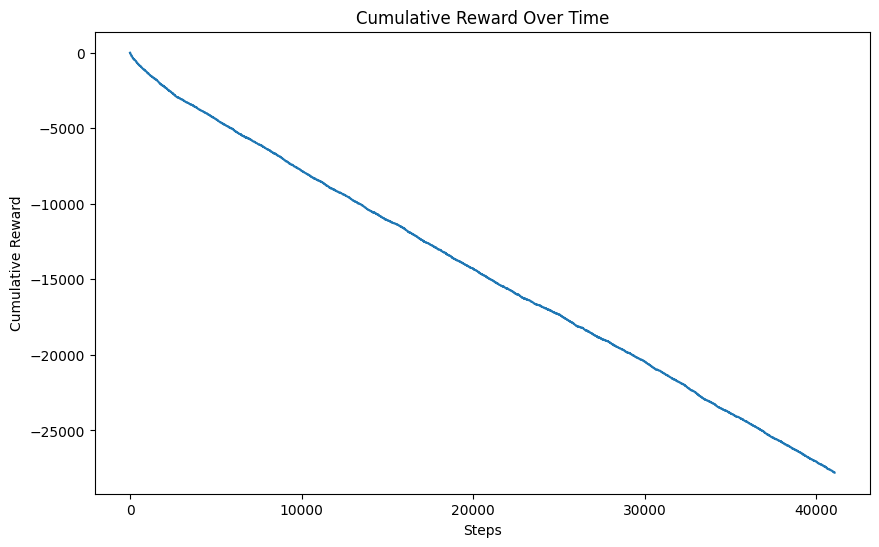

In [41]:
cumulative_reward = np.cumsum(reward_history)

plt.figure(figsize=(10,6))
plt.plot(cumulative_reward)
plt.title("Cumulative Reward Over Time")
plt.xlabel("Steps")
plt.ylabel("Cumulative Reward")
plt.show()

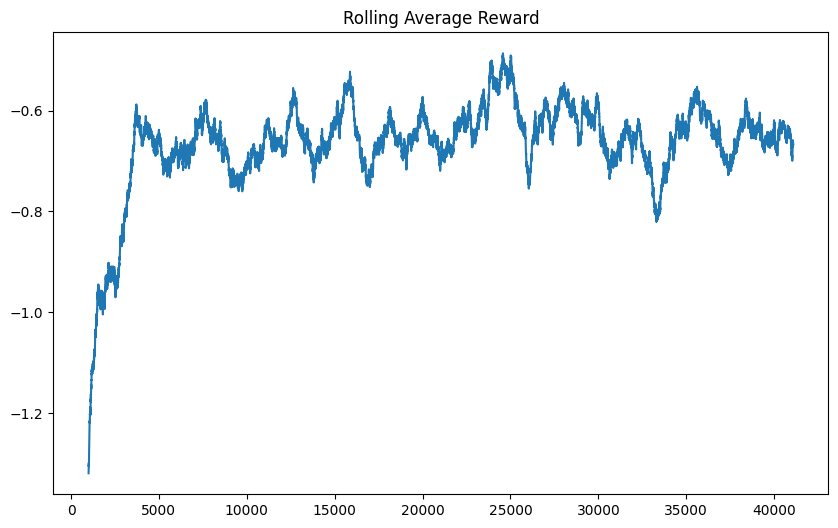

In [43]:
window = 1000
pd.Series(reward_history).rolling(window).mean().plot(figsize=(10,6))
plt.title("Rolling Average Reward")
plt.show()

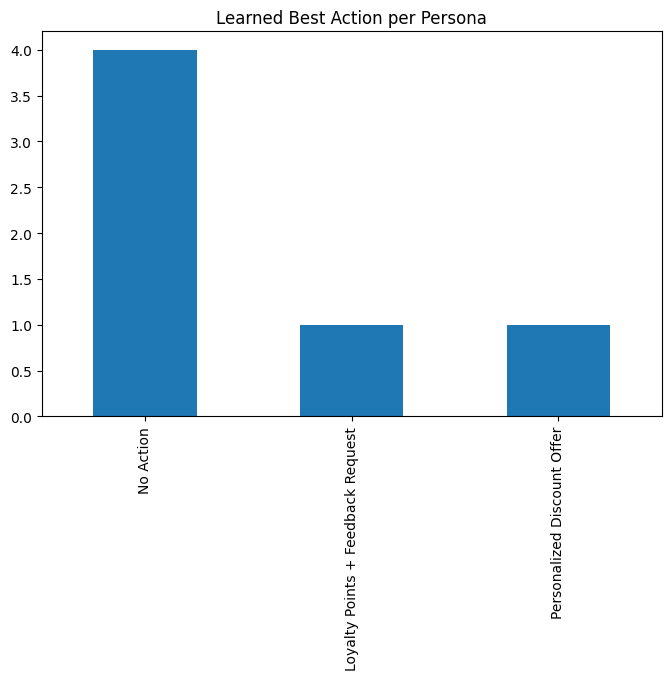

In [44]:
policy_counts = learned_policy.value_counts()

policy_counts.plot(kind="bar", figsize=(8,5))
plt.title("Learned Best Action per Persona")
plt.show()